In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils_lstm import LSTMAttentionModel, train_model, evaluate_model, plot_importance, sliding_window_importance
from sklearn.preprocessing import MinMaxScaler

In [2]:
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])

import numpy as np

# Keep features with variance above a threshold
variance_threshold = 0.09
dfs = dfs.loc[:, dfs.var() > variance_threshold]
targets

,Unnamed: 0,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,0,2,0.000000,0.317461,0.337050,0.626034,0.344543
1,1,2,0.022036,0.319825,0.363018,0.600159,0.372211
2,2,2,0.044072,0.319035,0.401244,0.560835,0.412939
3,3,2,0.066108,0.317768,0.438220,0.522651,0.452336
4,4,2,0.088145,0.320230,0.465094,0.495879,0.480970
...,...,...,...,...,...,...,...
4616,14374,314,0.903482,0.602647,0.400094,0.641878,0.341981
4617,14375,314,0.925518,0.618405,0.398324,0.648210,0.340095
4618,14376,314,0.947554,0.631936,0.397945,0.652486,0.339691
4619,14377,314,0.969590,0.640013,0.399376,0.653355,0.341216


In [3]:
angle = 45
# Collect the 6th row's Main-axis value per experiment
selected = []
for exp_id, group in targets.groupby("Experiment_ID"):
    if len(group) > 6:  
        value = group.iloc[angle] # 6th row by position
    else:
        value = np.nan  # if experiment shorter than 7 rows
    selected.append([value])  # wrap in list → keeps (num_experiments, 1)

y = np.array(selected, dtype=float)[:,0,1:]
y = np.array(y)
groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)

X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)
y = np.nan_to_num(y, nan=0.0)[:,2:]
print("Shape:", X.shape, y.shape)  
# Convert to tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y)

Shape: (100, 1743, 6) (100, 4)


In [5]:
model = LSTMAttentionModel(input_size=X_tensor.shape[2], hidden_size=32, output_size=y_tensor.shape[1], dropout=0.3)
model = train_model(model, X_tensor, y_tensor, epochs=100, lr=0.001, batch_size=32, print_every=1)

Training: 100%|██████████| 100/100 [00:56<00:00,  1.76epoch/s, avg_loss=0.00598121]


In [6]:
# Evaluate
output, attn_weights, loss_val = evaluate_model(model, X_tensor, y_tensor)

# Sliding window importance (optional)
importance_scores = sliding_window_importance(model, X_tensor[0], y_tensor[0], window_size=10, stride=5)


Final Loss: 0.00596615
Predicted: [[0.20115373 0.3368994  0.5711328  0.31385362]
 [0.20132945 0.33732694 0.571742   0.31423697]
 [0.2016514  0.33774123 0.57242286 0.314663  ]
 [0.20174643 0.3381631  0.5729745  0.31501427]
 [0.20199403 0.33858335 0.57361794 0.31541902]
 [0.2021643  0.33900315 0.57421315 0.31579632]
 [0.2023311  0.33941758 0.57479864 0.31616884]
 [0.20243175 0.33985138 0.5753706  0.31653225]
 [0.20245908 0.34029144 0.5759061  0.31687433]
 [0.2028432  0.34068424 0.5765959  0.31730977]
 [0.2029389  0.34111017 0.5771541  0.3176667 ]
 [0.2030305  0.34152976 0.57770056 0.31801784]
 [0.20312913 0.34196186 0.57826924 0.31838098]
 [0.2034456  0.34237283 0.57894313 0.3188071 ]
 [0.20368195 0.34277844 0.5795599  0.319201  ]
 [0.20370223 0.34320885 0.580078   0.31953585]
 [0.20393753 0.3436134  0.58069295 0.3199294 ]
 [0.20410663 0.344037   0.58129364 0.32031336]
 [0.20434135 0.34444165 0.58190864 0.32070756]
 [0.20436028 0.34487087 0.58242446 0.32104227]
 [0.2045213  0.34528136 0.

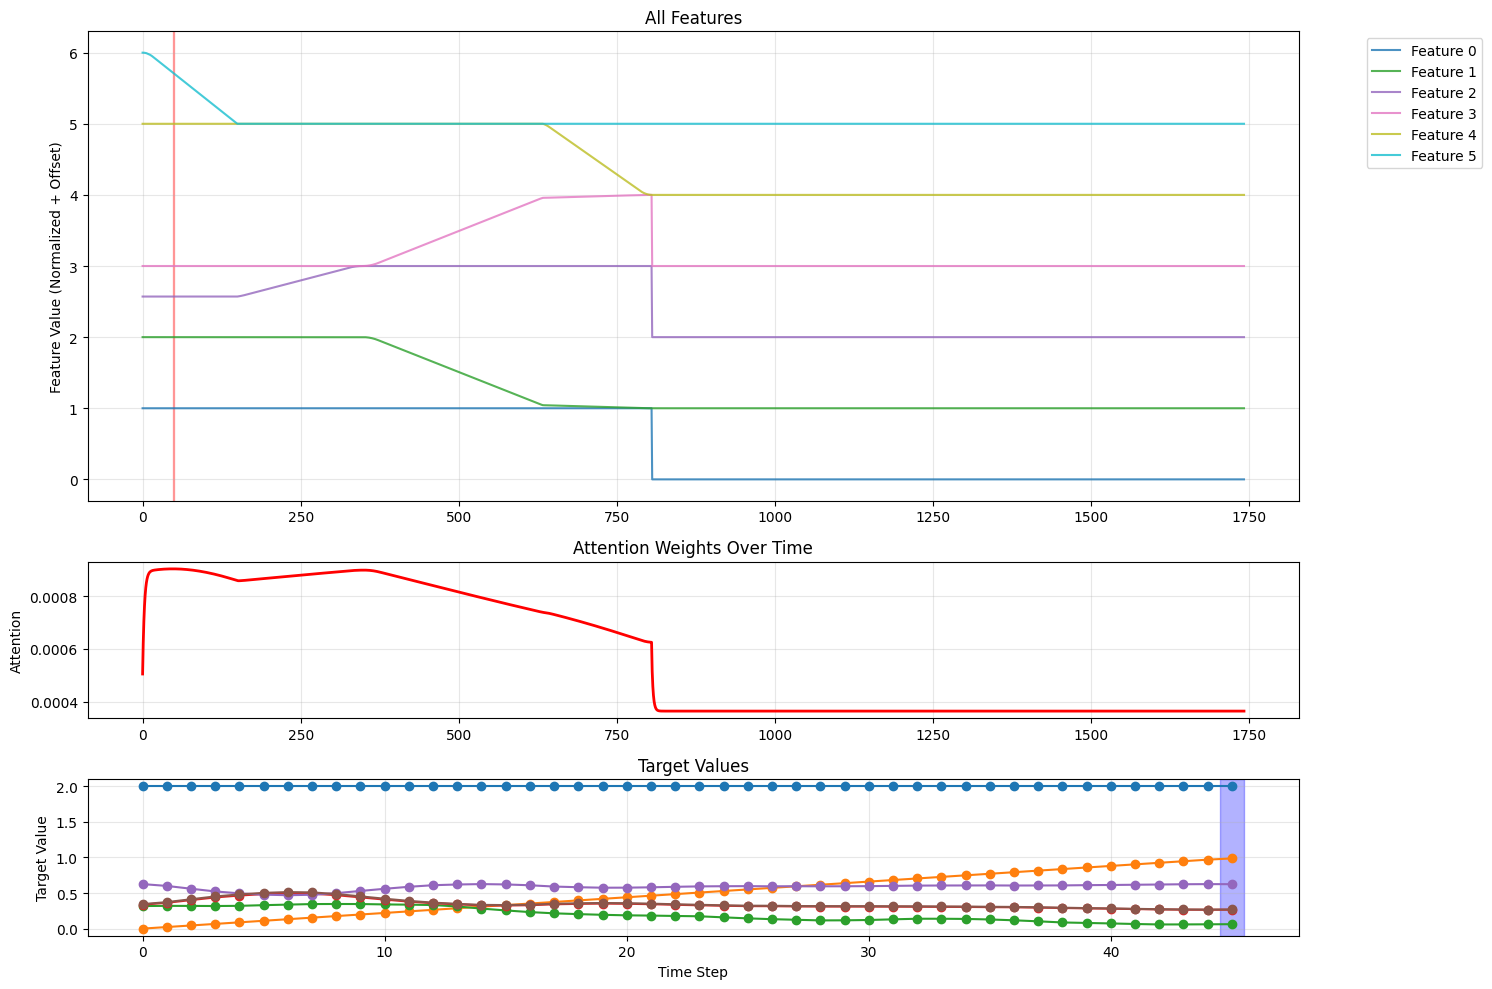

In [8]:
experiment_id = 2
target = targets[targets["Experiment_ID"]==experiment_id].iloc[:, 1:]
# Plot results with highest-attended area highlighted
plot_importance(X[experiment_id-2], scores=importance_scores, target=target, attn_weights=attn_weights[experiment_id-2],top_n=10, target_angle=angle)